# Rotary Position Embeddings (RoPE) — From Scratch

We will build RoPE from first principles.

No `transformers` library.
No built-in RoPE implementation.
No hiding the important mathematics.

We will start with something very simple:

> What does it actually mean to rotate a vector?

Then we will gradually build:

1. 2D vector rotation
2. Position-dependent rotation
3. Rotating Q and K
4. Relative-position property
5. Extension to higher dimensions
6. RoPE frequencies
7. Complete RoPE implementation
8. RoPE inside self-attention
9. RoPE + KV cache during inference

In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from ipywidgets import interact, FloatSlider

plt.rcParams["figure.figsize"] = (7, 7)
plt.rcParams["axes.grid"] = True

In [2]:
x = np.array([1.0, 0.0])

print("x =", x)

x = [1. 0.]


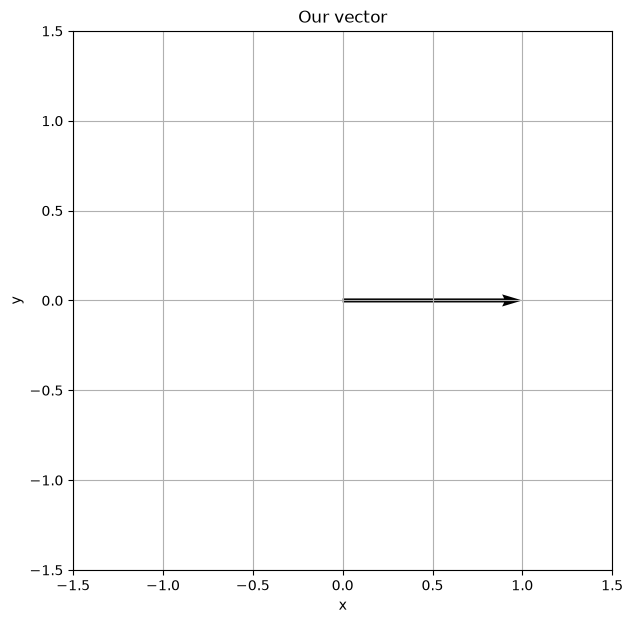

In [3]:
fig, ax = plt.subplots()

ax.quiver(
    0, 0,
    x[0], x[1],
    angles="xy",
    scale_units="xy",
    scale=1
)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Our vector")

plt.show()

In [4]:
theta = math.radians(45)

print("theta =", theta)
print("theta in degrees =", math.degrees(theta))

theta = 0.7853981633974483
theta in degrees = 45.0


In [5]:
x_rotated = np.array([
    math.cos(theta),
    math.sin(theta)
])

print(x_rotated)

[0.70710678 0.70710678]


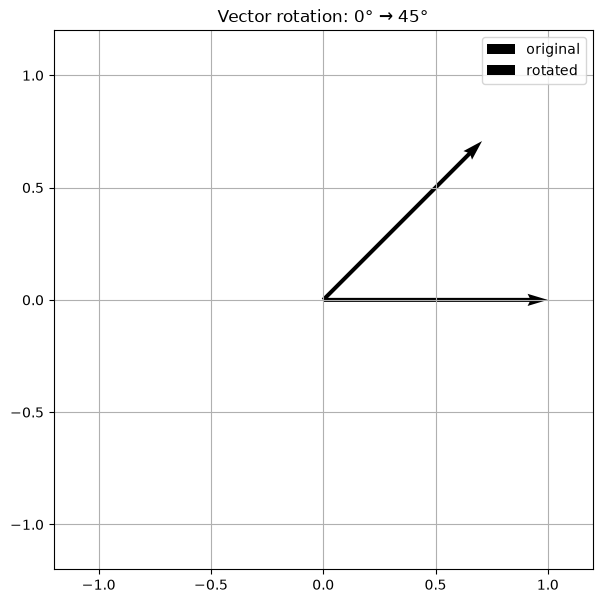

In [6]:
fig, ax = plt.subplots()

# Original
ax.quiver(
    0, 0,
    x[0], x[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label="original"
)

# Rotated
ax.quiver(
    0, 0,
    x_rotated[0], x_rotated[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label="rotated"
)

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")

ax.legend()
ax.set_title("Vector rotation: 0° → 45°")

plt.show()

In [7]:
def rotate_vector(angle_degrees):

    theta = math.radians(angle_degrees)

    rotated = np.array([
        math.cos(theta),
        math.sin(theta)
    ])

    fig, ax = plt.subplots()

    ax.quiver(
        0, 0,
        1, 0,
        angles="xy",
        scale_units="xy",
        scale=1,
        alpha=0.3
    )

    ax.quiver(
        0, 0,
        rotated[0],
        rotated[1],
        angles="xy",
        scale_units="xy",
        scale=1
    )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.set_title(f"Rotation = {angle_degrees:.0f}°")

    plt.show()


interact(
    rotate_vector,
    angle_degrees=FloatSlider(
        min=0,
        max=360,
        step=5,
        value=45
    )
);

interactive(children=(FloatSlider(value=45.0, description='angle_degrees', max=360.0, step=5.0), Output()), _d…

In [8]:
theta = np.radians(45)

R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

print(R)

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
